#### Python Libraries necessary for the tasks

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import os
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.callbacks import EarlyStopping
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from transformers import BertTokenizer, TFBertForSequenceClassification

In [2]:
df = pd.read_csv("Twitter US Airline Sentiment Dataset/Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

Columns that are not related to the sentiment classification were removed. This include the metadata fields and columns with a high proportion of missing values, as they do not contribute to the objective. 
The necessary columns has no missing values.

In [4]:
# Check for missing values
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [5]:
# Drop unused columns
df = df.drop(columns=["tweet_id", "name", "tweet_coord", "airline_sentiment_confidence", "negativereason", 
                      "negativereason_confidence", "airline_sentiment_gold", "negativereason_gold", "retweet_count", 
                      "tweet_created", "tweet_location", "user_timezone"])

In [6]:
# Verify that the columns have been dropped
df

,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


In [7]:
# Check the class distributions of the sentiment
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

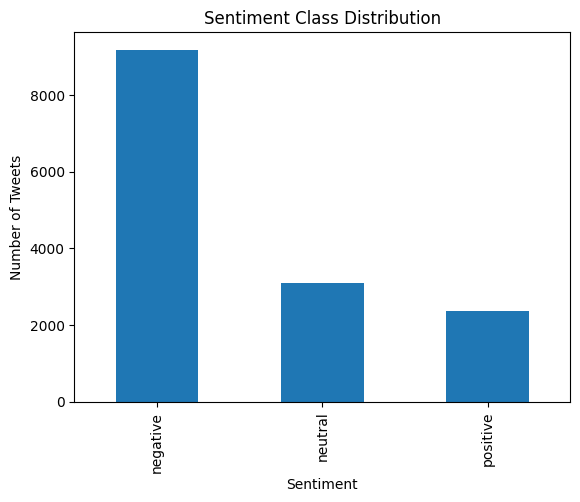

In [8]:
# Visualize the class distributions
df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

The dataset is highly imbalanced, with negative tweets occurring most frequently.

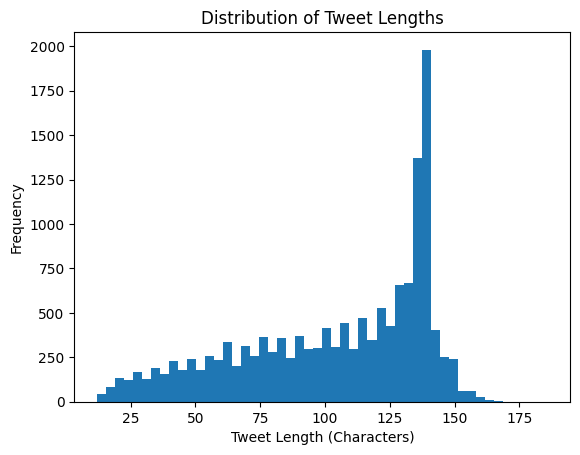

In [9]:
# Visualize the tweet lengths
tweet_lengths = df['text'].apply(len)

plt.hist(tweet_lengths, bins=50)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length (Characters)")
plt.ylabel("Frequency")
plt.show()

Tweet lengths vary significantly. Most tweets contained longer characters, which suggests padding.

In [10]:
# Establish a majority-class baseline benchmark
df['airline_sentiment'].value_counts().max() / len(df)

0.6269125683060109

### Preprocessing

#### Data Cleaning

In [11]:
def clean_text(text):
    """
    Converts text to lowercase
    Remove URLs, mentions, hashtags, numbers, punctutaion, and extra whitespace
    """
    text = text.lower()                           # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)    # Remove URLs
    text = re.sub(r"@\w+", "", text)              # Remove mentions
    text = re.sub(r"#", "", text)                  # Remove hashtag symbol
    text = re.sub(r"\d+", "", text)               # Remove numbers
    text = re.sub(r"[^\w\s]", "", text)           # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip()      # Remove extra spaces
    
    return text

In [12]:
# Apply the cleaning function to the dataframe
df['text'] = df['text'].apply(clean_text)

In [13]:
df

,airline_sentiment,airline,text
0,neutral,Virgin America,what said
1,positive,Virgin America,plus youve added commercials to the experience...
2,neutral,Virgin America,i didnt today must mean i need to take another...
3,negative,Virgin America,its really aggressive to blast obnoxious enter...
4,negative,Virgin America,and its a really big bad thing about it
...,...,...,...
14635,positive,American,thank you we got on a different flight to chicago
14636,negative,American,leaving over minutes late flight no warnings o...
14637,neutral,American,please bring american airlines to blackberry
14638,negative,American,you have my money you change my flight and don...


#### Tokenization

Tokenized the sentences into individual words 

In [14]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [15]:
def tokenize_text(text):
    """
    Tokenizes text using spaCy.
    """
    return [token.text for token in nlp(text)]

In [16]:
# Apply function to tokenize
tokens = df['text'].apply(tokenize_text)

In [17]:
# Verify
tokens.head()

0                                         [what, said]
1    [plus, you, ve, added, commercials, to, the, e...
2    [i, did, nt, today, must, mean, i, need, to, t...
3    [its, really, aggressive, to, blast, obnoxious...
4    [and, its, a, really, big, bad, thing, about, it]
Name: text, dtype: object

#### Remove Stopwords

In [18]:
def remove_stopwords(text):
    """
    Removes stopwords using spaCy.
    """
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop]

In [19]:
# Apply the function to remove stopwords, and verify
tokens_no_stopwords = df['text'].apply(remove_stopwords)
tokens_no_stopwords.head()

0                                               [said]
1    [plus, ve, added, commercials, experience, tacky]
2                        [nt, today, mean, need, trip]
3    [aggressive, blast, obnoxious, entertainment, ...
4                                    [big, bad, thing]
Name: text, dtype: object

#### Apply Lemmatization

In [20]:
def lemmatization(texts, nlp, batch_size=500):
    """
    Lemmatizes a list of text strings using spaCy's nlp.pipe()
    """
    lemmatized = []

    for doc in nlp.pipe(texts, batch_size=batch_size):
        lemmatized.append(" ".join([token.lemma_ for token in doc]))

    return lemmatized

In [21]:
texts = df["text"].astype(str).tolist()   # Convert text column to a Python list

lemmatized_texts = lemmatization(texts, nlp, batch_size=500)     # Apply the lemmatization function

# Print sample
print('Lemmatized texts[:5]', lemmatized_texts[:5])

Lemmatized texts[:5] ['what say', 'plus you ve add commercial to the experience tacky', 'I do not today must mean I need to take another trip', 'its really aggressive to blast obnoxious entertainment in your guest face amp they have little recourse', 'and its a really big bad thing about it']


### Genrerating Wordcloud

In [22]:
def generate_wordcloud(texts):
    """
    Generate and display a word cloud from a list of text strings.
    """
    # Join all texts into one large string
    combined_text = " ".join(texts)

    # Create the word cloud
    wc = WordCloud().generate(combined_text)

    # Plot the word cloud
    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.show()

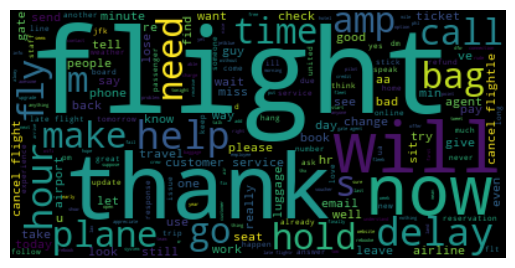

In [23]:
generate_wordcloud(lemmatized_texts)

#### Vectorisation with TF-IDF

In [27]:
# X = input texts (lemmatized)
X_text = lemmatized_texts

# y = labels
y = df['airline_sentiment']

In [28]:
# Split the dataset into training and testing sets

X_train_text, X_test_text, y_train, y_test = train_test_split(
    lemmatized_texts,
    df['airline_sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['airline_sentiment']     # This ensures class distribution is preserved
)


In [29]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # Use unigrams and bigrams
    max_features=20000,    # Keep 20000 most important words
    min_df=5               # Remove words that appear in less than 5 documents
)

# Fit the vectorizer on the training text only (to avoid data leakage)
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Transform the test text using the fitted vectorizer
X_test_tfidf = tfidf.transform(X_test_text)

# Display the shape of the feature matrices
print("TF-IDF Training Data Shape:", X_train_tfidf.shape)
print("TF-IDF Test Data Shape:", X_test_tfidf.shape)

TF-IDF Training Data Shape: (11712, 7181)
TF-IDF Test Data Shape: (2928, 7181)


Text was converted into numerical features using TF-IDF vectorisation.
Unigrams and bigrams were included to capture short phrases such as "flight delay" or "not happy".
The vectoriser was fitted on the training data only, to avoid information leakage, and then applied to the test set.


# Traditional Machine Learning Models

##### Computing class priors from the training labels to solve the imbalance problem

In [30]:
# Calculate class distribution in training set
class_counts = y_train.value_counts().sort_index()  

# Convert to probabilities
class_priors = class_counts / class_counts.sum()

print("\nClass priors (used to handle imbalance):")
print(class_priors)


Class priors (used to handle imbalance):
airline_sentiment
negative    0.626964
neutral     0.211663
positive    0.161373
Name: count, dtype: float64


### Train Naive Bayes Classifier

Using TF-IDF and Class priors

In [31]:
def train_evaluate_naive_bayes(X_train, y_train, X_test, y_test, class_priors):
    """
    Trains a Multinomial Naive Bayes model and evaluates its performance.
    """
    # Initialise the model with class priors to handle imbalance
    model = MultinomialNB(class_prior=class_priors.values)

    # Train the model
    model.fit(X_train, y_train)

    # Predict the labels for the test data
    y_pred = model.predict(X_test)

    # Evaluate the metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    # Print results
    print("Naive Bayes Accuracy:", accuracy)
    print("\nClassification Report:\n", report)

    return model, y_pred, accuracy

In [32]:
# Apply the function to train the model
nb_model, y_pred_nb, nb_accuracy = train_evaluate_naive_bayes(
    X_train_tfidf,
    y_train,
    X_test_tfidf,
    y_test,
    class_priors
)

Naive Bayes Accuracy: 0.7387295081967213

Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.98      0.84      1835
     neutral       0.73      0.25      0.37       620
    positive       0.89      0.43      0.58       473

    accuracy                           0.74      2928
   macro avg       0.78      0.55      0.59      2928
weighted avg       0.75      0.74      0.70      2928



#### Plot Confusion Matrix

Created a function code reusable for the confusion matrix plots. 

In [33]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title):
    """
    Plots a confusion matrix as a heatmap.
    """
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    # Print raw counts
    print("\nConfusion Matrix (raw counts):")
    print(cm)

    # Plot heatmap
    plt.figure
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()


Confusion Matrix (raw counts):
[[1806   24    5]
 [ 445  154   21]
 [ 238   32  203]]


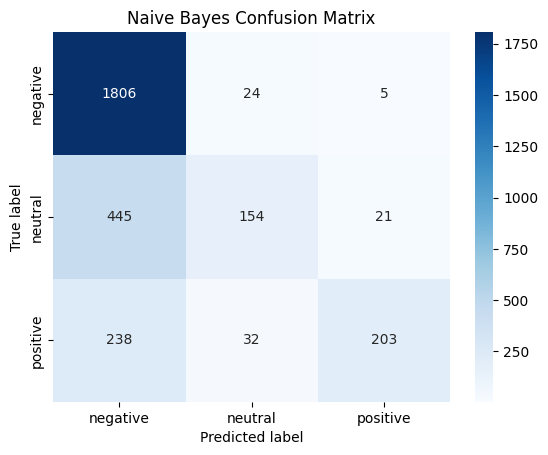

In [34]:
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    nb_model.classes_,
    title="Naive Bayes Confusion Matrix"
)

Although Naive Bayes achieved a reasonable overall accuracy (74%), its performance varied widely across sentiment classes. The model achieved very high recall for negative tweets but performed poorly on the neutral and positive classes. This shows that the classifier was strongly biased toward the majority class which is the negative class, despite using class priors to mitigate the imbalance. Naive Bayes struggled particularly with neutral sentiment.

#### Perform Hyperparameter adjustment to optimize the Naive Bayes model

Tuned the smoothing parameter alpha using GridSearchCV, including the use of class priors

In [35]:
# Define a function to refine te model
def tune_naive_bayes(X_train, y_train, class_priors):
    """
    Tunes the smoothing parameter alpha for Multinomial Naive Bayes
    using GridSearchCV and returns model.
    """
    # Initialise the model with class priors to handle imbalance
    nb = MultinomialNB(class_prior=class_priors.values)

    # Define the grid of alpha values to search over
    param_grid = {
        'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
    }

    # Set up GridSearchCV
    grid_search = GridSearchCV(
        estimator=nb,
        param_grid=param_grid,
        cv=3,                       # 3 fold cross validation
        scoring='f1_macro',         # f1_macro is used to balance performance across all the classes
        n_jobs=-1
    )

    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)

    # Print best parameters and score
    print("Best parameters (Naive Bayes):", grid_search.best_params_)
    print("Best CV F1-macro:", grid_search.best_score_)

    # Return the best model
    return grid_search.best_estimator_

In [36]:
# Tune Naive Bayes and get the best model
nb_tuned = tune_naive_bayes(X_train_tfidf, y_train, class_priors)

Best parameters (Naive Bayes): {'alpha': 0.1}
Best CV F1-macro: 0.678520555137356


##### Evaluate the tuned Naive Bayes model

In [37]:
# Predict on the test set using the tuned model
y_pred_nb_tuned = nb_tuned.predict(X_test_tfidf)

# Calculate accuracy
nb_accuracy_tuned = accuracy_score(y_test, y_pred_nb_tuned)
print("Tuned Naive Bayes Accuracy:", nb_accuracy_tuned)

# Show classification report
print("\nClassification Report (Tuned Naive Bayes):")
print(classification_report(y_test, y_pred_nb_tuned))

Tuned Naive Bayes Accuracy: 0.7848360655737705

Classification Report (Tuned Naive Bayes):
              precision    recall  f1-score   support

    negative       0.79      0.96      0.87      1835
     neutral       0.73      0.43      0.54       620
    positive       0.82      0.56      0.67       473

    accuracy                           0.78      2928
   macro avg       0.78      0.65      0.69      2928
weighted avg       0.78      0.78      0.77      2928




Confusion Matrix (raw counts):
[[1762   50   23]
 [ 314  269   37]
 [ 155   51  267]]


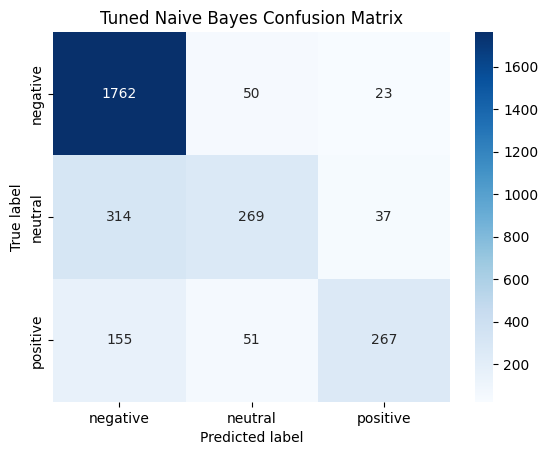

In [38]:
# Apply the plot confusion matrix function on the tuned model 
plot_confusion_matrix(
    y_test,
    y_pred_nb_tuned,
    nb_tuned.classes_,
    title="Tuned Naive Bayes Confusion Matrix"
)

Tuning the smoothing parameter alpha significantly improved the performance of the model. 
The Macro F1-score increased from 0.59 to 0.69, and the overall accuracy improved from 74% to 78%.
The largest gains were observed for the minority classes (neutral and positive), particularly the neutral sentiment, whose recall increased from 0.25 to 0.43.
This shows that hyperparameter tuning and class priors helped to mitigate the class imbalance.

### Train the SVM 

Trained a Linear SVM Classifier, and using class weight to handle class imbalance by giving more weight to minority classes during training.

In [39]:
# Define a function to train the linear SVM
def train_evaluate_svm(X_train, y_train, X_test, y_test):
    """
    Trains a Linear Support Vector Machine (SVM) classifier on TF-IDF features
    and evaluates its performance on the test set.
    """

    # Initialize a Linear SVM classifier
    svm_model = LinearSVC(class_weight="balanced", random_state=42)      
    
    
    # Train the SVM model 
    svm_model.fit(X_train, y_train)
    
    # Predict sentiment labels on the test set
    y_pred = svm_model.predict(X_test)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print("SVM Accuracy:", accuracy)
    
    # Print classification metrics (precision, recall, F1-score)
    print("\nClassification Report (SVM):")
    print(classification_report(y_test, y_pred))
    
    return svm_model, y_pred, accuracy

In [40]:
# Call the function to train the SVM model
svm_model, y_pred_svm, svm_accuracy = train_evaluate_svm(
    X_train_tfidf,
    y_train,
    X_test_tfidf,
    y_test
)

SVM Accuracy: 0.79474043715847

Classification Report (SVM):
              precision    recall  f1-score   support

    negative       0.87      0.88      0.88      1835
     neutral       0.61      0.65      0.63       620
    positive       0.74      0.68      0.71       473

    accuracy                           0.79      2928
   macro avg       0.74      0.73      0.74      2928
weighted avg       0.80      0.79      0.80      2928




Confusion Matrix (raw counts):
[[1607  175   53]
 [ 162  400   58]
 [  69   84  320]]


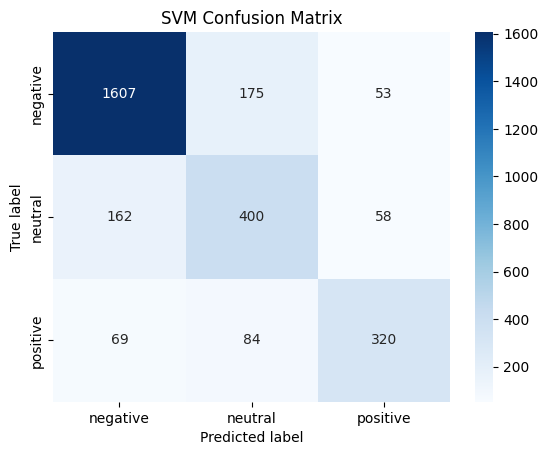

In [41]:
# Use the plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_svm,
    svm_model.classes_,
    title="SVM Confusion Matrix"
)

The SVM model outperformed Naive Bayes, particularly on the minority classes. The macro F1-score increased to 0.74, which indicates more balanced performance across all the sentiment classes. Neutral and positive tweets were classified more accurately than with Naive Bayes, showing that SVM is better suited for handling high-dimensional sparse text features produced by TF-IDF.

Although, SVM improved the performance, it will be tuned to further refine the model for better performance

#### Tune SVM parameter regularization strength (c) using Grid Search CV

The regularisation parameter C was tuned using GridSearchCV with three-fold cross-validation.

In [42]:
# Define the function for tuning SVM
def tune_svm(X_train, y_train, X_test, y_test):
    """
    Tunes the regularisation parameter C for a Linear SVM classifier using GridSearchCV,
    then evaluates the best model on the test set.
    """
    
    # Initialise Linear SVM model.
    svm = LinearSVC(class_weight="balanced", random_state=42)
    
    # Define the grid of C values (regularisation strength) to search over.
    param_grid = {
        'C': [0.1, 0.5, 1.0, 2.0, 5.0]    # Smaller C gives stronger regularisation,Larger C gives weaker regularisation 
    }
    
    # Set up GridSearchCV to perform cross-validation over the C values.
    grid_search = GridSearchCV(
        estimator=svm,
        param_grid=param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )
    
    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)
    
    # Print the best hyperparameters and cross-validated F1-macro score
    print("Best parameters (SVM):", grid_search.best_params_)
    print("Best CV F1-macro (SVM):", grid_search.best_score_)
    
    # Get the best model found by grid search
    best_model = grid_search.best_estimator_
    
    # Evaluate the best model on the test set
    y_pred = best_model.predict(X_test)
    best_accuracy = accuracy_score(y_test, y_pred)
    
    print("\nTuned SVM Accuracy on test set:", best_accuracy)
    print("\nClassification Report (Tuned SVM):")
    print(classification_report(y_test, y_pred))
    
    return best_model, y_pred, best_accuracy

In [43]:
# Call the function
svm_best, y_pred_svm_tuned, svm_accuracy_tuned = tune_svm(
    X_train_tfidf,
    y_train,
    X_test_tfidf,
    y_test
)

Best parameters (SVM): {'C': 0.1}
Best CV F1-macro (SVM): 0.7412012866240038

Tuned SVM Accuracy on test set: 0.8128415300546448

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

    negative       0.87      0.91      0.89      1835
     neutral       0.67      0.65      0.66       620
    positive       0.77      0.66      0.71       473

    accuracy                           0.81      2928
   macro avg       0.77      0.74      0.75      2928
weighted avg       0.81      0.81      0.81      2928




Confusion Matrix (raw counts):
[[1663  127   45]
 [ 168  403   49]
 [  83   76  314]]


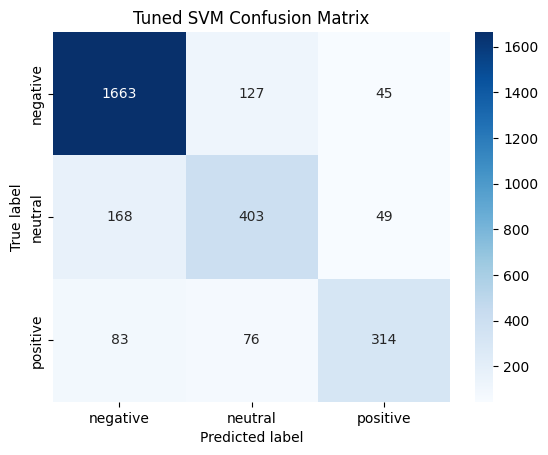

In [44]:
# Plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_svm_tuned,
    svm_best.classes_,
    title="Tuned SVM Confusion Matrix"
)

Hyperparameter tuning significantly improved SVM performance. 
After tuning the regularisation parameter C using GridSearchCV, accuracy improved from 0.79 to 0.81 and macro F1-score increased from 0.74 to 0.75. 
The tuned SVM showed better balance across all classes, especially improving classification of neutral and positive classes. 
This confirms that SVM performs better than Naive Bayes for high-dimensional textual features.

# Deep Learning Models

### Train LSTM 

In [45]:
# Extract texts and labels for deep learning
texts_dl = df['text'].astype(str).values
labels = df['airline_sentiment'].values

# Encode sentiment labels as integers (negative=0, neutral=1, positive=2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Split into train and test sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts_dl,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Further split training into train and validation
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.1,          # 10% of train for validation
    random_state=42,
    stratify=y_train
)

print("Train size:", len(X_train_text))
print("Validation size:", len(X_val_text))
print("Test size:", len(X_test_text))

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Train size: 10540
Validation size: 1172
Test size: 2928


#### Tokenize and pad sequences

In [46]:
# Maximum number of words to keep in the vocabulary
MAX_WORDS = 20000

# Maximum number of tokens per tweet
MAX_LEN = 50

# Initialise the tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Fit tokenizer on training text only
tokenizer.fit_on_texts(X_train_text)

In [47]:
# Define function to convert text to padded sequences
def texts_to_padded_sequences(texts, tokenizer, max_len=MAX_LEN):
    """
    Converts a list of text strings into padded integer sequences.
    """
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded

# Convert train, validation, and test sets to padded sequences
X_train_seq = texts_to_padded_sequences(X_train_text, tokenizer, MAX_LEN)
X_val_seq   = texts_to_padded_sequences(X_val_text, tokenizer, MAX_LEN)
X_test_seq  = texts_to_padded_sequences(X_test_text, tokenizer, MAX_LEN)

print("Train sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Train sequence shape: (10540, 50)
Validation sequence shape: (1172, 50)
Test sequence shape: (2928, 50)


#### Compute class weights to handle the class imbalance

In [48]:
# Compute class weights based on the training labels
classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to dictionary format 
class_weights = {int(cls): weight for cls, weight in zip(classes, class_weights_arr)}

print("Class weights for LSTM:", class_weights)

Class weights for LSTM: {0: 0.531678773204197, 1: 1.5747796204990288, 2: 2.065451695081325}


### Build LSTM 

For the deep learning approach, an LSTM model was trained using tokenised and padded tweet sequences to ensure consistent input size. An Embedding layer was used to learn dense vector representations of the words, followed by an LSTM layer and a fully connected softmax output layer. Labels were encoded as integers (0, 1,2) and class weights were applied during training to minimize the impact of class imbalance. 

In [49]:
def train_evaluate_lstm(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    vocab_size,
    max_len,
    class_weights=None,
    embedding_dim=128,
    lstm_units=[64],
    dropout_rate=0.3,
    learning_rate=0.001,
    epochs=5,
    batch_size=64,
    use_early_stopping=False,
    patience=2
):
    """
    Builds, trains, and evaluates an LSTM model for text classification.

    This function can be used both for:
    Baseline training ( default hyperparameters)
    Fine-tuning (by changing hyperparameters and enabling early stopping)
    """

    # Build the LSTM model 
    model = Sequential()

    # Add embedding layer  (learns dense vectors for each word index)
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))

    # LSTM layer to process the sequence of embeddings
    # Add one or multiple LSTM layers
    for i, units in enumerate(lstm_units):
        # For all layers except last, return sequences=True
        return_seq = (i < len(lstm_units) - 1)
        model.add(LSTM(units, return_sequences=return_seq))


    # Dropout layer to help reduce overfitting
    model.add(Dropout(dropout_rate))

    # Output layer: 3 units (for 3 classes) with softmax activation
    model.add(Dense(3, activation='softmax'))

    # Compile the model with Adam optimiser and appropriate loss
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])

    model.build(input_shape=(None, max_len))
    model.summary()

    # Set up callbacks (EarlyStopping is optional)
    callbacks = []
    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        )
        callbacks.append(early_stop)

    # Train the model
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, 
                        class_weight=class_weights, callbacks=callbacks, verbose=1)

    # Evaluate on the test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print("\nLSTM Test Accuracy:", test_acc)

    # Predict class probabilities on the test set
    y_pred_probs = model.predict(X_test)
    # Convert probabilities to class labels
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Print classification report with original class names
    print("\nClassification Report (LSTM):")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    return model, history, y_pred, test_acc

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Vocabulary size used for LSTM:", vocab_size)

Vocabulary size used for LSTM: 10471


In [50]:
def plot_training_history(history):
    """
    Plots training and validation accuracy and loss .
    """
    # Extract metrics from history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(1, len(acc) + 1)
    
    # Create figure
    plt.figure(figsize=(12, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

#### Train the default LSTM model

In [51]:
# Call the train and evaluate LSTM function to train the model
lstm_baseline, lstm_history_baseline, y_pred_lstm_baseline, lstm_acc_baseline = train_evaluate_lstm(
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    class_weights=class_weights,  
    embedding_dim=128,
    lstm_units=[64],
    dropout_rate=0.3,
    learning_rate=0.001,
    epochs=10,
    batch_size=64,
    use_early_stopping=False       
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 128)           1340288   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 3)                 195       
                                                                 
Total params: 1389891 (5.30 MB)
Trainable params: 1389891 (5.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10


165/165 [==============================] - 14s 59ms/step - loss: 1.1000 - accuracy: 0.3132 - val_loss: 1.1114 - val_accuracy: 0.1613
Epo

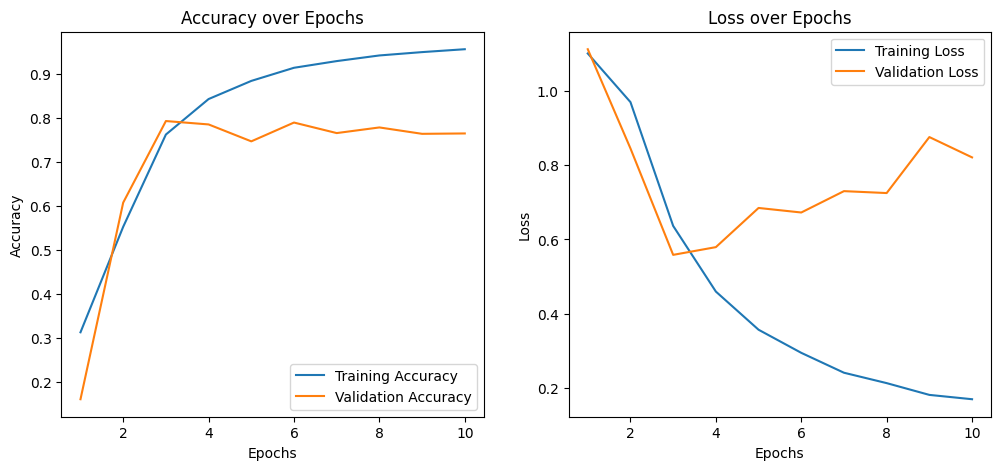

In [52]:
# Call the function to plot
plot_training_history(lstm_history_baseline)


Confusion Matrix (raw counts):
[[1556  195   84]
 [ 182  346   92]
 [  84   62  327]]


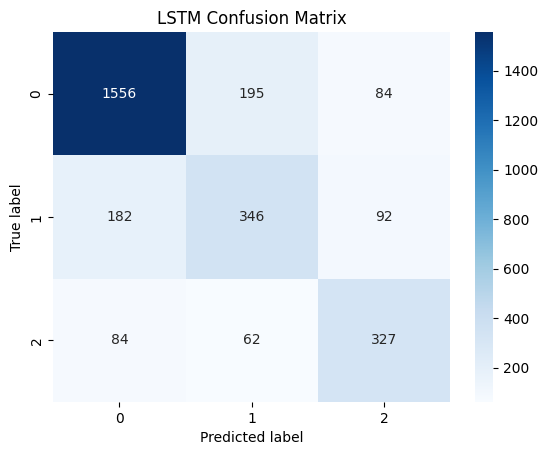

In [53]:
# Call function to plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_lstm_baseline,
    list(range(len(label_encoder.classes_))),
    title="LSTM Confusion Matrix"
) 

### Hyperparameter Tuning (LSTM)

##### Increased dropout rate to 0.5, and enabled earlystopping with patience of 2

In [54]:
# Call the function
lstm_tuned, lstm_history_tuned, y_pred_lstm_tuned, lstm_acc_tuned = train_evaluate_lstm(
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    class_weights=class_weights,
    embedding_dim=128,
    lstm_units=[64],
    dropout_rate=0.5,         
    learning_rate=0.001,       
    epochs=10,                 
    batch_size=64,
    use_early_stopping=True,   
    patience=2
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 50, 128)           1340288   
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 3)                 195       
                                                                 
Total params: 1389891 (5.30 MB)
Trainable params: 1389891 (5.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
165/165 [==============================] - 17s 64ms/step - loss: 1.1002 - accuracy: 0.3354 - val_loss: 1.0029 - val_accuracy: 0.6271
Epoc

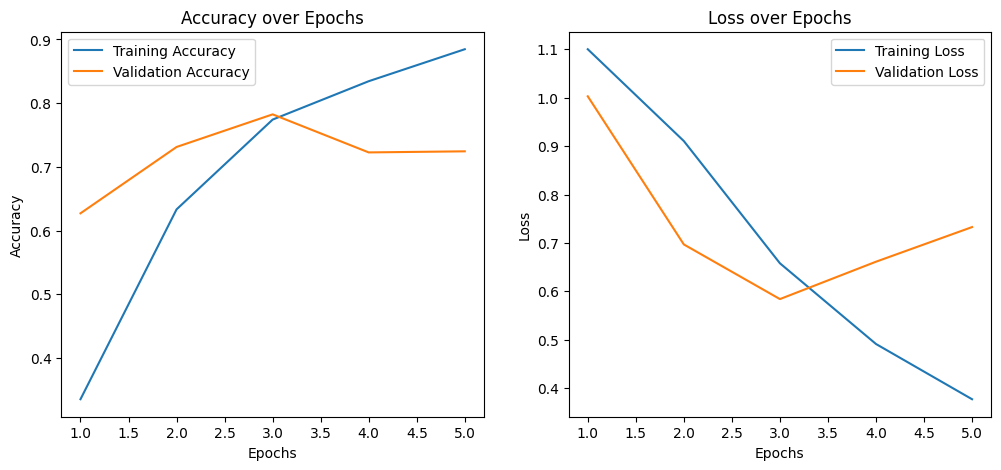

In [55]:
# Call the function to plot
plot_training_history(lstm_history_tuned)


Confusion Matrix (raw counts):
[[1533  217   85]
 [ 152  379   89]
 [  53   69  351]]


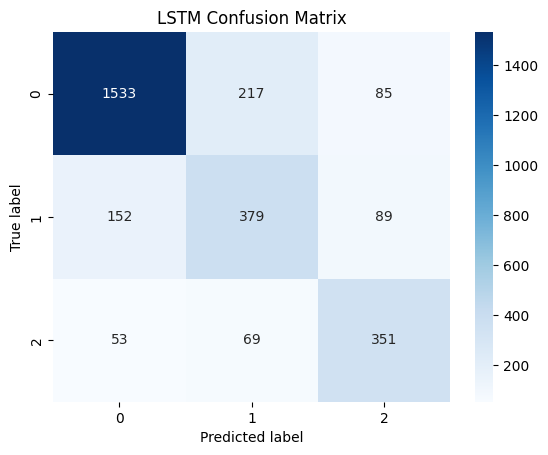

In [56]:
# Call function to plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_lstm_tuned,
    list(range(len(label_encoder.classes_))),
    title="LSTM Confusion Matrix"
)

##### Increased epoch to 15, and used two LSTM units [64,128].

In [58]:
# Call the function
lstm_tuned2, lstm_history_tuned2, y_pred_lstm_tuned2, lstm_acc_tuned2 = train_evaluate_lstm(
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    class_weights=class_weights,
    embedding_dim=128,
    lstm_units=[64,128],
    dropout_rate=0.5,         
    learning_rate=0.001,       
    epochs=15,                 
    batch_size=64,
    use_early_stopping=True,   
    patience=2
)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 50, 128)           1340288   
                                                                 
 lstm_4 (LSTM)               (None, 50, 64)            49408     
                                                                 
 lstm_5 (LSTM)               (None, 128)               98816     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 3)                 387       
                                                                 
Total params: 1488899 (5.68 MB)
Trainable params: 1488899 (5.68 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/15
165/1

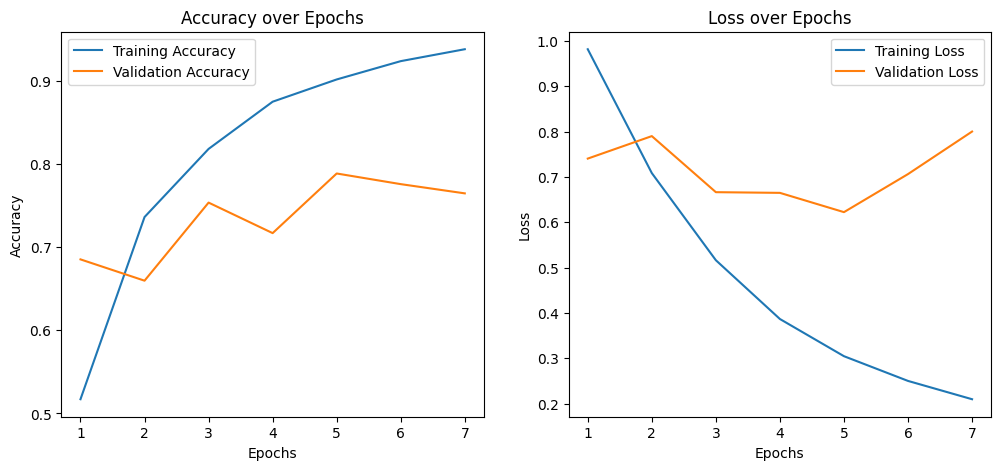

In [59]:
# Call the function to plot
plot_training_history(lstm_history_tuned2)


Confusion Matrix (raw counts):
[[1576  208   51]
 [ 162  415   43]
 [  83   94  296]]


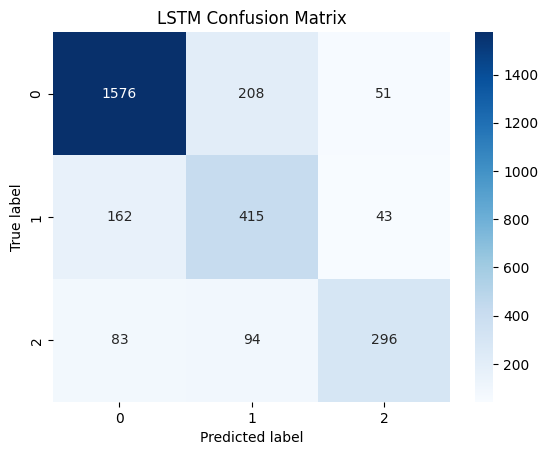

In [60]:
# Call function to plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_lstm_tuned2,
    list(range(len(label_encoder.classes_))),
    title="LSTM Confusion Matrix"
)

##### 10 epoch, batch size of 64, dropout rate of 0.5, learning rate of 0.001 and the two LSTM units [64,128].

In [65]:
# Call the function
lstm_tuned4, lstm_history_tuned4, y_pred_lstm_tuned4, lstm_acc_tuned4 = train_evaluate_lstm(
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    vocab_size=vocab_size,
    max_len=MAX_LEN,
    class_weights=class_weights,
    embedding_dim=128,
    lstm_units=[64,128],
    dropout_rate=0.5,         
    learning_rate=0.001,       
    epochs=10,                 
    batch_size=64,
    use_early_stopping=False,   
    patience=2
)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 50, 128)           1340288   
                                                                 
 lstm_10 (LSTM)              (None, 50, 64)            49408     
                                                                 
 lstm_11 (LSTM)              (None, 128)               98816     
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 3)                 387       
                                                                 
Total params: 1488899 (5.68 MB)
Trainable params: 1488899 (5.68 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
165/1

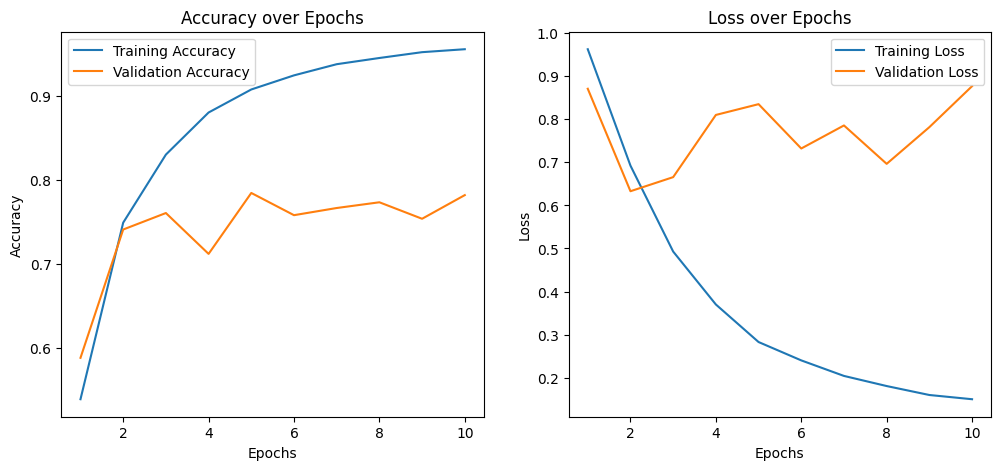

In [66]:
# Call the function to plot
plot_training_history(lstm_history_tuned4)


Confusion Matrix (raw counts):
[[1539  240   56]
 [ 167  392   61]
 [  94   89  290]]


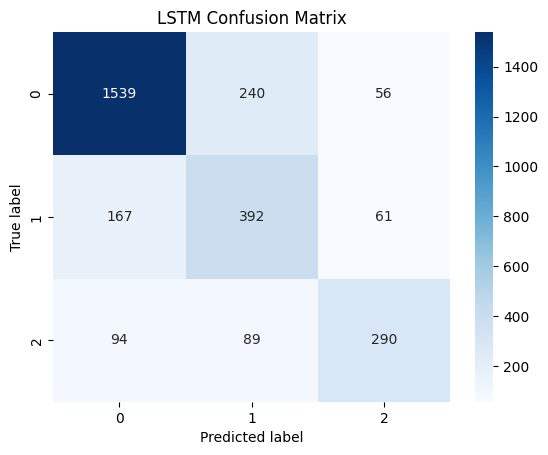

In [67]:
# Call function to plot confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_lstm_tuned4,
    list(range(len(label_encoder.classes_))),
    title="LSTM Confusion Matrix"
)

### Train BERT

BERT (`bert-base-uncased`) was used as a transformer-based model for sentiment analysis. 
A default version was trained with frozen layers, while a fine-tuned version updated all model weights. 
Results were evaluated using accuracy and classification metrics.

In [68]:
def train_evaluate_bert(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    num_classes=3,
    model_name="bert-base-uncased",
    max_len=64,
    batch_size=16,
    epochs=2,
    learning_rate=2e-5,
    freeze_bert=False,
    class_weights=None
):
    """
    Trains and evaluates a BERT classifier for sentiment analysis.

    Can be used for:
    - Baseline training (freeze_bert=True, few epochs)
    - Fine-tuning (freeze_bert=False, lower learning rate, more epochs)
    
    Parameters control learning rate, epochs, freezing layers, and class weighting.
    """

    # Tokeniser 
    tokenizer = BertTokenizer.from_pretrained(model_name)

    def encode_texts(texts):
        return tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="tf"
        )

    # Encode datasets
    train_enc = encode_texts(X_train)
    val_enc   = encode_texts(X_val)
    test_enc  = encode_texts(X_test)

    # Build BERT 
    model = TFBertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        use_safetensors=False   
    )

    # Optionally freeze BERT layers
    if freeze_bert:
        print("BERT layers frozen (baseline mode).")
        model.bert.trainable = False
    else:
        print("BERT fully trainable (fine-tuning mode).")

    # Compile model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

    # Train the model
    history = model.fit(
        x=dict(train_enc),
        y=y_train,
        validation_data=(dict(val_enc), y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights
    )

    # Evaluate model
    test_logits = model.predict(dict(test_enc)).logits
    y_pred = np.argmax(test_logits, axis=1)

    acc = accuracy_score(y_test, y_pred)
    print("\nBERT Test Accuracy:", acc)

    print("\nClassification Report (BERT):")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    return model, history, y_pred, acc

### Train the default BERT model, with the layers frozen

In [72]:
# Call the function to train default model (Feature extractor only)
bert_baseline, hist_base, y_pred_base, acc_base = train_evaluate_bert(
    X_train_text, y_train,
    X_val_text, y_val,
    X_test_text, y_test,
    freeze_bert=True,        # freeze the encoder
    epochs=2,
    batch_size=16,
    learning_rate=2e-5,
    class_weights=class_weights
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT layers frozen (baseline mode).
Epoch 1/2
659/659 [==============================] - 1083s 2s/step - loss: 1.0982 - accuracy: 0.4120 - val_loss: 1.0472 - val_accuracy: 0.5683
Epoch 2/2
92/92 [==============================] - 231s 2s/step

BERT Test Accuracy: 0.5894808743169399

Classification Report (BERT):
              precision    recall  f1-score   support

    negative       0.76      0.70      0.73      1835
     neutral       0.38      0.37      0.38       620
    positive       0.33      0.43      0.37       473

    accuracy                           0.59      2928
   macro avg       0.49      0.50      0.49      2928
weighted avg       0.61      0.59      0.60      2928



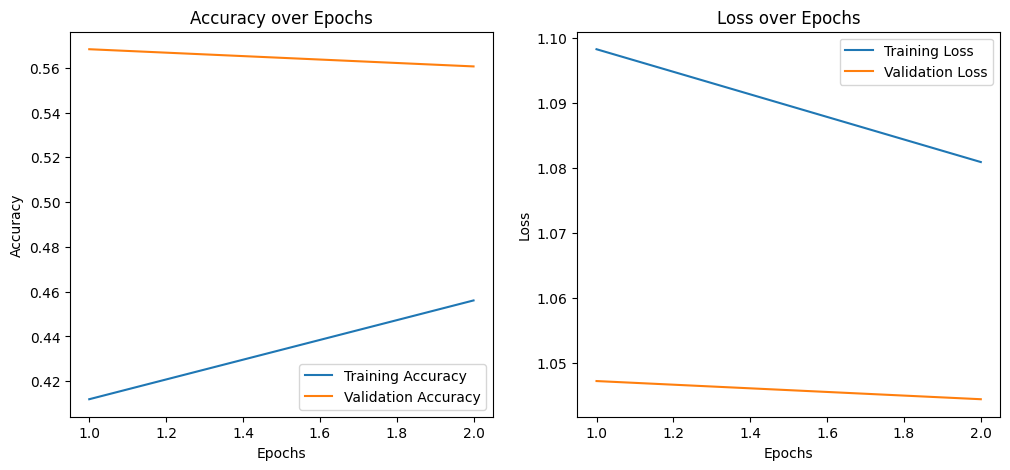

In [73]:
plot_training_history(hist_base)


Confusion Matrix (raw counts):
[[1292  268  275]
 [ 244  232  144]
 [ 158  113  202]]


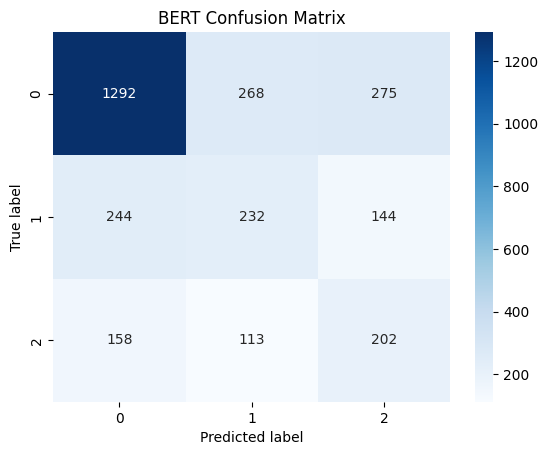

In [75]:
# Plot the confusion matrix using the function created earlier
plot_confusion_matrix(
    y_test,
    y_pred_base,
    list(range(len(label_encoder.classes_))),
    title="BERT Confusion Matrix"
)

#### Hyperparameter Tuning (BERT)

#### Epoch of 2, learning rate of 2e-6, batch size of 16,  and unfreeze all layers

In [76]:
# Call the function to train the fine-tuned model
bert_tunedd, hist_tunedd, y_pred_tunedd, acc_tunedd = train_evaluate_bert(
    X_train_text, y_train,
    X_val_text, y_val,
    X_test_text, y_test,
    freeze_bert=False,      
    epochs=2,
    batch_size=16,
    learning_rate=2e-6,
    class_weights=class_weights
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT fully trainable (fine-tuning mode).
Epoch 1/2
659/659 [==============================] - 2989s 4s/step - loss: 0.9038 - accuracy: 0.6443 - val_loss: 0.6307 - val_accuracy: 0.7568
Epoch 2/2
92/92 [==============================] - 238s 2s/step

BERT Test Accuracy: 0.7766393442622951

Classification Report (BERT):
              precision    recall  f1-score   support

    negative       0.92      0.78      0.85      1835
     neutral       0.57      0.73      0.64       620
    positive       0.67      0.82      0.74       473

    accuracy                           0.78      2928
   macro avg       0.72      0.78      0.74      2928
weighted avg       0.81      0.78      0.78      2928



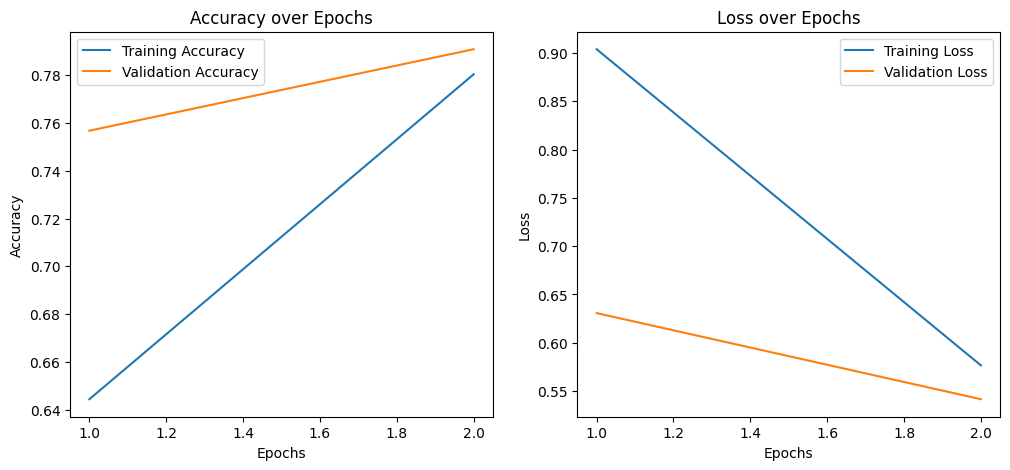

In [77]:
plot_training_history(hist_tunedd)


Confusion Matrix (raw counts):
[[1436  289  110]
 [  90  451   79]
 [  31   55  387]]


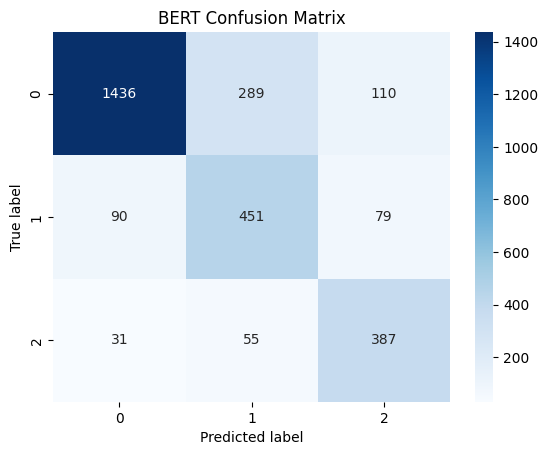

In [78]:
# Plot the confusion matrix using the function created earlier
plot_confusion_matrix(
    y_test,
    y_pred_tunedd,
    list(range(len(label_encoder.classes_))),
    title="BERT Confusion Matrix"
)

#### Epoch of 4, learning rate of 2e-5, and Unfreeze all layers

In [79]:
# Call the function to train the fine-tuned model
bert_tuned, hist_tuned, y_pred_tuned, acc_tuned = train_evaluate_bert(
    X_train_text, y_train,
    X_val_text, y_val,
    X_test_text, y_test,
    freeze_bert=False,       # unfreeze all layers
    epochs=4,
    batch_size=16,
    learning_rate=2e-5,
    class_weights=class_weights
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT fully trainable (fine-tuning mode).
Epoch 1/4
659/659 [==============================] - 3503s 5s/step - loss: 0.3653 - accuracy: 0.8676 - val_loss: 0.4781 - val_accuracy: 0.8285
Epoch 3/4
659/659 [==============================] - 3104s 5s/step - loss: 0.2194 - accuracy: 0.9256 - val_loss: 0.5303 - val_accuracy: 0.8302
Epoch 4/4
92/92 [==============================] - 202s 2s/step

BERT Test Accuracy: 0.8292349726775956

Classification Report (BERT):
              precision    recall  f1-score   support

    negative       0.90      0.91      0.90      1835
     neutral       0.66      0.70      0.68       620
    positive       0.79      0.69      0.74       473

    accuracy                           0.83      2928
   macro avg       0.78      0.77      0.77      2928
weighted avg       0.83      0.83      0.83      2928



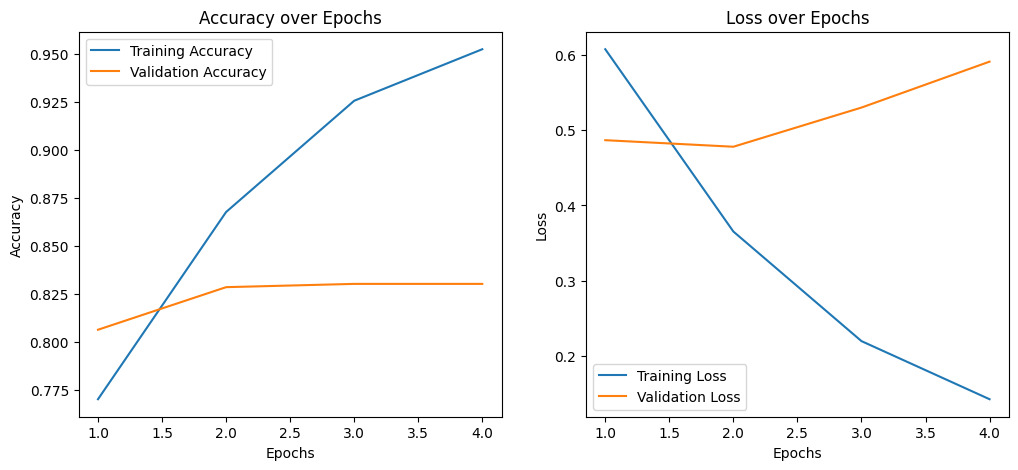

In [80]:
plot_training_history(hist_tuned)


Confusion Matrix (raw counts):
[[1666  128   41]
 [ 140  436   44]
 [  51   96  326]]


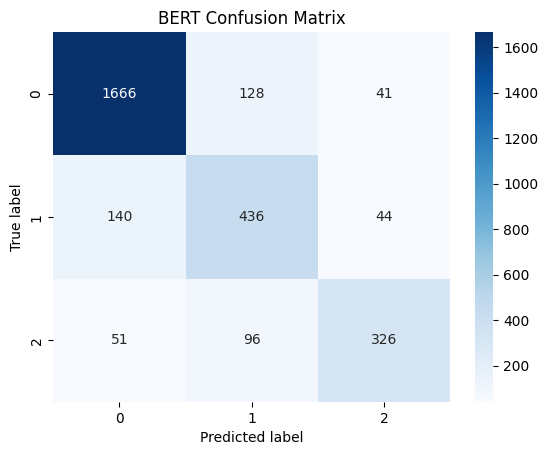

In [81]:
# Plot the confusion matrix using the function created earlier
plot_confusion_matrix(
    y_test,
    y_pred_tuned,
    list(range(len(label_encoder.classes_))),
    title="BERT Confusion Matrix"
)

#### Compared Naive Bayes, SVM, LSTM, and BERT using the accuracy and macro F1 score for the best performed in each model

In [86]:
# Compare the four models using the best accuracy and macro F1
results_summary = pd.DataFrame({
    "Model": ["Naive Bayes (tuned)", "SVM (tuned)", "LSTM (tuned)", "BERT (tuned)"],
    "Accuracy": [0.78, 0.81, 0.78, 0.83],
    "Macro F1": [0.69, 0.75, 0.72, 0.77]
    
})

results_summary

,Model,Accuracy,Macro F1
0,Naive Bayes (tuned),0.78,0.69
1,SVM (tuned),0.81,0.75
2,LSTM (tuned),0.78,0.72
3,BERT (tuned),0.83,0.77
